In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'Y dataset')

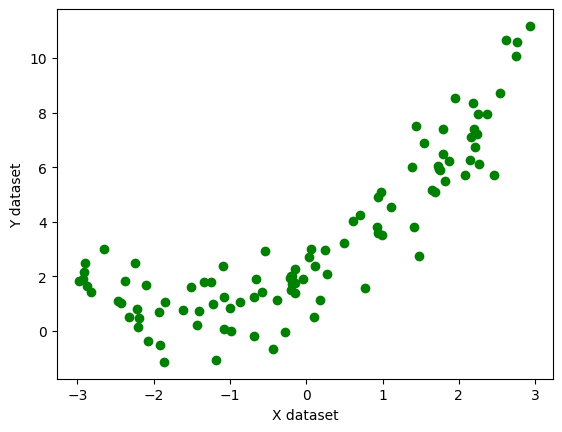

In [7]:
X = 6 * np.random.rand(100,1) - 3
y = 0.5 * X**2 + 1.5 * X + 2 + np.random.randn(100,1) # Qudaratic eq. y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
# Implement the simple linear Regression
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [16]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
from sklearn.metrics import r2_score
score = r2_score(y_test,regression_1.predict(X_test))
print(score)

0.6864963282783977


Text(0, 0.5, 'Y')

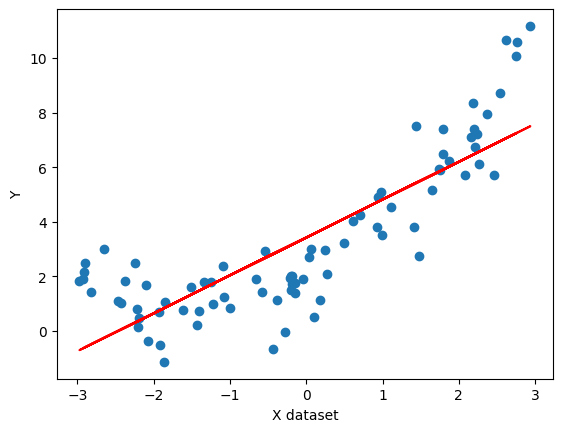

In [18]:
# Visualizing the model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X dataset")
plt.ylabel("Y")

In [19]:
# Lets apply the polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [20]:
X_train_poly

array([[ 1.00000000e+00, -2.24403629e+00,  5.03569886e+00],
       [ 1.00000000e+00, -1.08511041e+00,  1.17746459e+00],
       [ 1.00000000e+00,  9.26990169e-01,  8.59310773e-01],
       [ 1.00000000e+00,  1.10816155e+00,  1.22802203e+00],
       [ 1.00000000e+00,  2.74477512e+00,  7.53379044e+00],
       [ 1.00000000e+00,  2.54466090e+00,  6.47529911e+00],
       [ 1.00000000e+00, -2.97119217e+00,  8.82798293e+00],
       [ 1.00000000e+00, -2.06742194e+00,  4.27423348e+00],
       [ 1.00000000e+00, -4.30361988e-01,  1.85211440e-01],
       [ 1.00000000e+00,  6.75633566e-02,  4.56480716e-03],
       [ 1.00000000e+00, -2.10123902e+00,  4.41520541e+00],
       [ 1.00000000e+00,  1.44450081e+00,  2.08658259e+00],
       [ 1.00000000e+00, -1.07567525e+00,  1.15707724e+00],
       [ 1.00000000e+00, -1.85827238e-01,  3.45317624e-02],
       [ 1.00000000e+00,  2.62404382e+00,  6.88560596e+00],
       [ 1.00000000e+00,  1.87484101e+00,  3.51502880e+00],
       [ 1.00000000e+00, -9.92961776e-01

In [21]:
X_test_poly

array([[ 1.        ,  1.69211398,  2.86324972],
       [ 1.        , -0.9822304 ,  0.96477655],
       [ 1.        , -0.86444453,  0.74726434],
       [ 1.        ,  2.25424445,  5.08161805],
       [ 1.        ,  2.14402112,  4.59682655],
       [ 1.        ,  0.11196552,  0.01253628],
       [ 1.        ,  1.72184976,  2.96476658],
       [ 1.        ,  0.77328952,  0.59797668],
       [ 1.        , -0.14862096,  0.02208819],
       [ 1.        ,  1.5403662 ,  2.37272802],
       [ 1.        , -1.07260305,  1.1504773 ],
       [ 1.        ,  0.94672445,  0.89628719],
       [ 1.        ,  1.8145619 ,  3.2926349 ],
       [ 1.        , -0.6879048 ,  0.47321301],
       [ 1.        ,  1.3818129 ,  1.9094069 ],
       [ 1.        , -2.8666091 ,  8.21744774],
       [ 1.        , -1.17900961,  1.39006366],
       [ 1.        , -2.32324152,  5.39745115],
       [ 1.        ,  1.95051426,  3.80450589],
       [ 1.        , -0.68054905,  0.46314701]])

In [22]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.8749639941629674


In [23]:
print(regression.coef_)

[[0.         1.44284409 0.48137768]]


In [24]:
print(regression.intercept_)

[1.97135877]


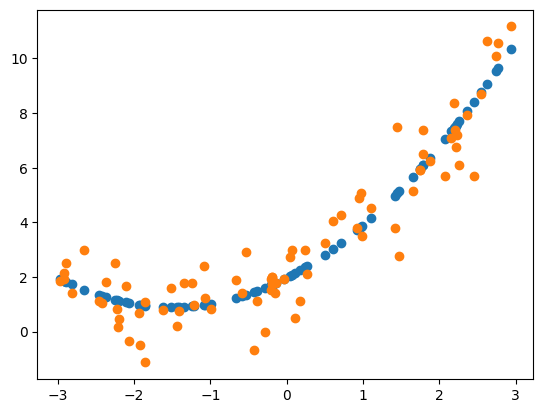

In [26]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [31]:
poly = PolynomialFeatures(degree=3,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [32]:
X_train_poly

array([[ 1.00000000e+00, -2.24403629e+00,  5.03569886e+00,
        -1.13002910e+01],
       [ 1.00000000e+00, -1.08511041e+00,  1.17746459e+00,
        -1.27767908e+00],
       [ 1.00000000e+00,  9.26990169e-01,  8.59310773e-01,
         7.96572639e-01],
       [ 1.00000000e+00,  1.10816155e+00,  1.22802203e+00,
         1.36084680e+00],
       [ 1.00000000e+00,  2.74477512e+00,  7.53379044e+00,
         2.06785605e+01],
       [ 1.00000000e+00,  2.54466090e+00,  6.47529911e+00,
         1.64774405e+01],
       [ 1.00000000e+00, -2.97119217e+00,  8.82798293e+00,
        -2.62296338e+01],
       [ 1.00000000e+00, -2.06742194e+00,  4.27423348e+00,
        -8.83664409e+00],
       [ 1.00000000e+00, -4.30361988e-01,  1.85211440e-01,
        -7.97079636e-02],
       [ 1.00000000e+00,  6.75633566e-02,  4.56480716e-03,
         3.08413694e-04],
       [ 1.00000000e+00, -2.10123902e+00,  4.41520541e+00,
        -9.27740189e+00],
       [ 1.00000000e+00,  1.44450081e+00,  2.08658259e+00,
      

In [33]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.8764660042813988


In [35]:
# Prediction of new data
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

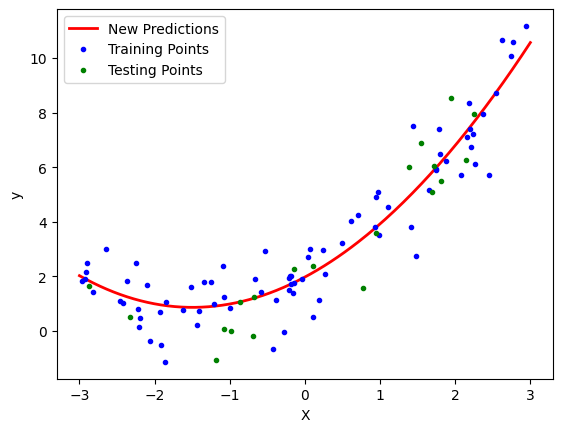

In [37]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new,y_new,"r-",linewidth=2,label="New Predictions")
plt.plot(X_train,y_train,"b.",label = "Training Points")
plt.plot(X_test,y_test,"g.",label="Testing Points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [38]:
# PIPELINE CONCEPT
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200,1)
    poly_features = PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) # polynomial and fit of LR
    y_pred_new = poly_regression.predict(X_new)

    # Plotting prediction Line
    plt.plot(X_new, y_pred_new,'r',label = "Degree" + str(degree),linewidth=3)
    plt.plot(X_train,y_train,'b.',linewidth=3)
    plt.plot(X_test,y_test,'g.',linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4,0,10])
    plt.show()

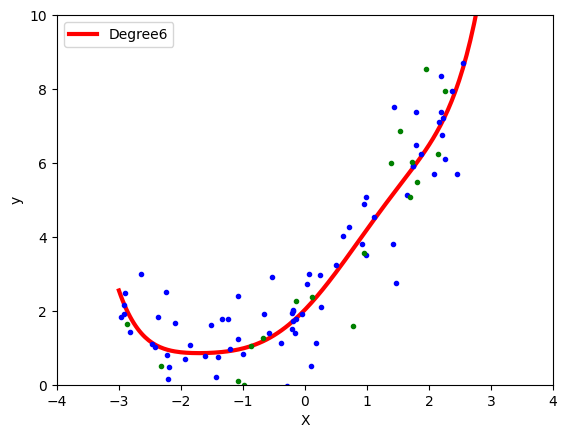

In [50]:
poly_regression(6)